# Содержание
- [Введение](#введение)
    - [Цель работы](#цель-работы)
    - [Постановка задачи](#постановка-задачи)
- [Описание датасета](#описание-датасета)
    - [Графики распределения признаков](notebook.ipynb#графики-распределения-признаков)
    




# Введение
## Цель работы
Изучение основ линейной регрессии, построение простейших моделей регрессии, проведение обучения модели на реальных данных и оценка её качество.
## Постановка задачи
1. Загрузить датасет из репозитория (например, kaggle.com или аналогичных платформ).

2. Подготовить данные: провести первичный анализ, визуализировать распределение признаков и целевой переменной. 

3. Провести предобработку данных: удалить пропущенные значения, закодировать категориальные переменные (опционально), нормализовать признаки.

4. Построить матрицу корреляций. Сделать выводы о наличии мультиколлинеарности (расчет VIF-коэффициента).

5. Построить регрессионные модели (линейная и гребневая). Если целевая переменная - категориальная, то исследовать логистическую регрессию. Разделить на тренировочную и тестовую выборки (80/20 или 70/30). Использовать кросс-валидацию. Оценить качество построенной модели с помощью метрик: RMSE (Root Mean Square Error), R² (коэффициент детерминации) и MAPE (Mean Absolute Percentage Error).

6. Устранить мультиколлинеарность и снизить размерность признаков с помощью метода главных компонент (PCA).

7. Повторить шаг 5 (линейная и гребневая регрессия), но использовать в качестве признаков не исходные данные, а главные компоненты. Сравнить метрики качества (RMSE, R² и MAPE) моделей, обученных на исходных данных и на главных компонентах.

# Описание датасета
[Concrete Compressive Strength Dataset](https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set)
Этот многомерный датасет содержит информацию о составе бетонных смесей и их возрасте для прогнозирования ключевого показателя качества — прочности на сжатие. Набор данных включает 1030 наблюдений с 8 признаками (количество цемента, шлака, золы-уноса, воды, пластификатора, крупного и мелкого заполнителя, а также возраст образца) и одной целевой переменной. Данные представлены в сыром виде и не содержат пропусков, что делает датасет готовым к использованию в задачах регрессионного анализа и машинного обучения.


|Название переменной|Тип данных|Единица измерения|Описание|Тип переменной|
|-|-|-|-|-|
|Cement|Числовая переменная|кг в м³ смеси|Количество цемента в смеси (Компонент 1)|Независимая|
|Blast Furnace Slag|Числовая переменная|кг в м³ смеси|Количество гранулированного доменного шлака (Компонент 2)|Независимая|
|Fly Ash|Числовая переменная|кг в м³ смеси|Количество золы-уноса (Компонент 3)|Независимая|
|Water|Числовая переменная|кг в м³ смеси|Количество воды (Компонент 4)|Независимая|
|Superplasticizer|Числовая переменная|кг в м³ смеси|Количество суперпластификатора (Компонент 5)|Независимая|
|Coarse Aggregate|Числовая переменная|кг в м³ смеси|Количество крупного заполнителя (Компонент 6)|Независимая|
|Fine Aggregate|Числовая переменная|кг в м³ смеси|Количество мелкого заполнителя (Компонент 7)|Независимая|
|Age|Числовая переменная|День (1-365)|Возраст бетона на момент испытания|Независимая|
|Concrete compressive strength|Числовая переменная|Мегапаскали (МПа)|Прочность бетона на сжатие|Зависимая|


In [15]:
import pandas
import matplotlib.pyplot as plt
import seaborn 
import numpy
import kagglehub
import math

# Загрузка данных
file_path = "concrete_data.csv"

df = kagglehub.dataset_load(
  kagglehub.KaggleDatasetAdapter.PANDAS,
  "elikplim/concrete-compressive-strength-data-set",
  file_path,
)

print(df.head())

   cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0            1040.0            676.0   28                          79.99  
1            1055.0            676.0   28                          61.89  
2             932.0            594.0  270                          40.27  
3             932.0            594.0  365                          41.05  
4             978.4            825.5  360                          44.30  


## Графики распределения признаков
Расчет количества интервалов по формуле Стержиса

In [ ]:
n = df.shape[0]
k = int(math.ceil(1 + math.log2(n)))
print(f"Количество записей: {n}")
print(f"Количество интервалов по формуле Стержиса: {k}")

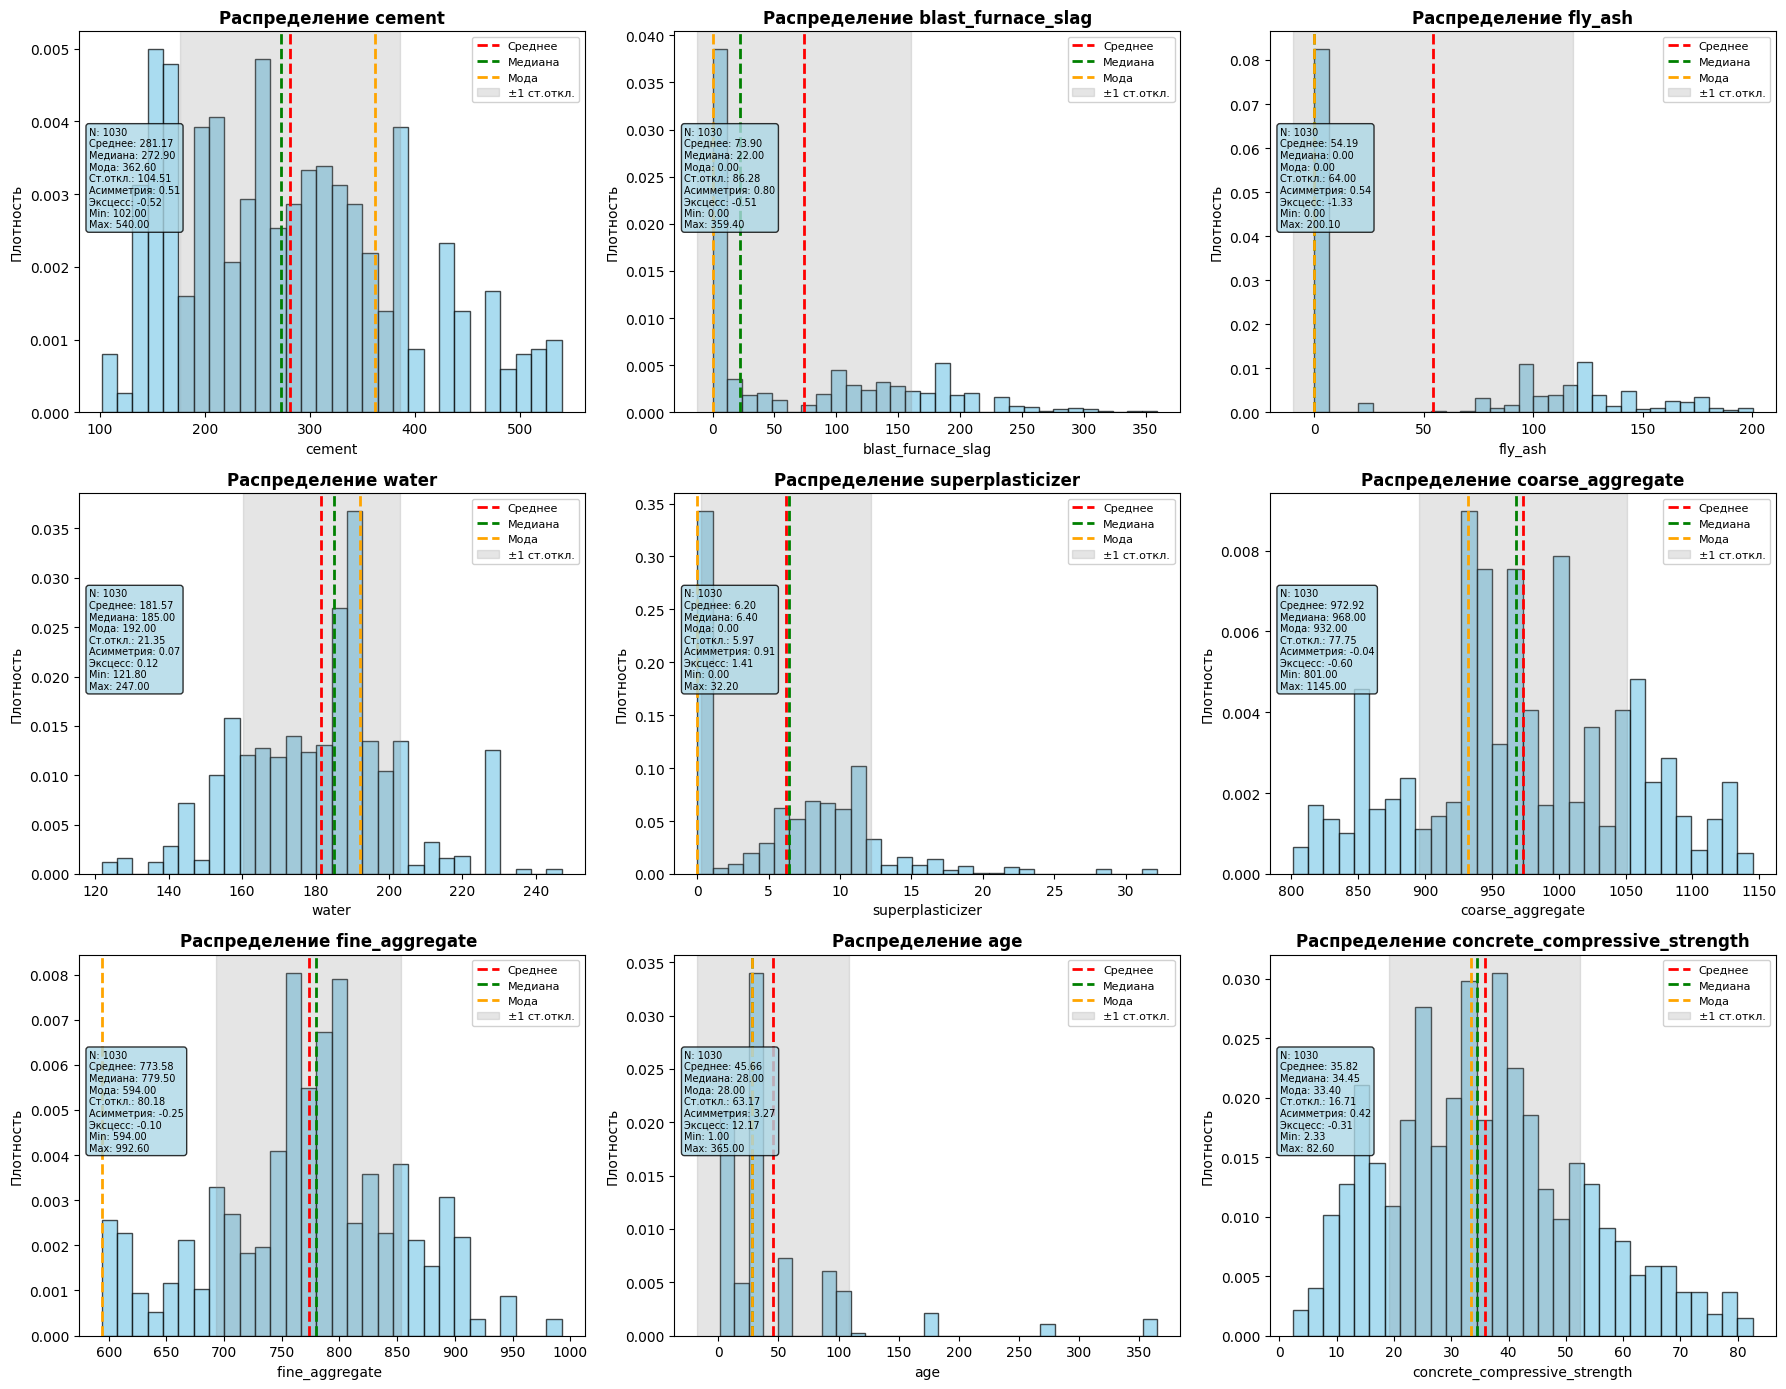

In [20]:
features = df.columns

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feature in enumerate(features):
    # Основная гистограмма
    axes[i].hist(df[feature], bins=30, alpha=0.7, color='skyblue', edgecolor='black', density=True)
    
    # Линии для моды, медианы и среднего
    mean_val = df[feature].mean()
    median_val = df[feature].median()
    mode_val = df[feature].mode()[0] if not df[feature].mode().empty else mean_val
    std_val = df[feature].std()
    skew_val = df[feature].skew()
    kurtosis_val = df[feature].kurtosis()
    
    # Добавляем вертикальные линии
    axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label='Среднее')
    axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label='Медиана')
    axes[i].axvline(mode_val, color='orange', linestyle='--', linewidth=2, label='Мода')
    
    # Добавляем стандартное отклонение (закрашенная область)
    axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='gray', 
                   label='±1 ст.откл.')
    
    # Настройка графика
    axes[i].set_title(f'Распределение {feature}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Плотность')
    
    # Добавляем легенду в правый верхний угол внутри графика
    axes[i].legend(loc='upper right', fontsize=8, framealpha=0.9)
    
    # Текстовая статистика в левом верхнем углу
    stats_text = (f'N: {len(df[feature])}\n'
                 f'Среднее: {mean_val:.2f}\n'
                 f'Медиана: {median_val:.2f}\n'
                 f'Мода: {mode_val:.2f}\n'
                 f'Ст.откл.: {std_val:.2f}\n'
                 f'Асимметрия: {skew_val:.2f}\n'
                 f'Эксцесс: {kurtosis_val:.2f}\n'
                 f'Min: {df[feature].min():.2f}\n'
                 f'Max: {df[feature].max():.2f}')
    
    axes[i].text(0.02, 0.75, stats_text, transform=axes[i].transAxes, 
                verticalalignment='top', fontsize=7,
                bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

plt.tight_layout()
plt.show()